## A simple one-dimensional second-order polynomial

We start with a very simple function,

$$
f(x) = 2 - x + 5x^2,
$$

defined for $x \in [-2, 2]$.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
n= 100
x = rng.uniform(-2, 2, n)
y = 2.0 - x + 5.0 * x**2 + 0.5 * rng.standard_normal(n)  

## Exercise 1: scale your data

## 1a

In [ ]:
x = np.column_stack([x, x**2])

#standardize the features
x_mean = x.mean(axis=0)
x_std = x.std(axis=0)
x_std[x_std==0]=1.0

x_norm = (x - x_mean) / x_std


y_mean = y.mean()
y_centered = y - y_mean

print("mean of x_norm:", np.round(x_norm.mean(axis=0), 12))
print("std of x_norm:", np.round(x_norm.std(axis=0), 12))

print("mean of y_centered:", np.round(y_centered.mean(), 12))


mean of x_norm: [-0.  0.]
std of x_norm: [1. 1.]
mean of y_centered: -0.0


Yes, we should centre $y$ because our design matrix does not contain a column
of ones, so the model does not have an intercept. Since the standardised
features have mean zero, the model predictions also have approximately zero
mean.

If we did not centre $y$, the model could not reproduce the non-zero mean of
the target. Its predictions would be shifted from the true values, resulting
in a larger mean squared error.

If the features are exactly centred, not centring $y$ does not change the
estimated coefficients of OLS or Ridge. However, the predictions would still
miss the mean of $y$. Another solution is to include an intercept in the model
and not penalise it in Ridge regression.

## 1b

The true function is

$$
y=2-x+5x^2+\varepsilon.
$$

Therefore, the original coefficient of $x$ is $-1$, the original coefficient
of $x^2$ is $5$, and the intercept is $2$.

The standardised features are

$$
z_1=\frac{x-\mu_1}{s_1},
\qquad
z_2=\frac{x^2-\mu_2}{s_2},
$$

where $\mu_1$ and $\mu_2$ are the feature means, and $s_1$ and $s_2$ are their
standard deviations.

Rearranging these equations gives

$$
x=\mu_1+s_1z_1,
\qquad
x^2=\mu_2+s_2z_2.
$$

Substituting these expressions into the true function gives

$$
y
=
2-(\mu_1+s_1z_1)
+5(\mu_2+s_2z_2)
+\varepsilon.
$$

Expanding the brackets gives

$$
y
=
2-\mu_1-s_1z_1
+5\mu_2+5s_2z_2
+\varepsilon.
$$

The constant part is

$$
2-\mu_1+5\mu_2.
$$

After centring the target, this constant part is removed. Therefore,

$$
y-\overline y
=
-s_1z_1+5s_2z_2+\varepsilon_c,
$$

where

$$
\varepsilon_c=\varepsilon-\overline{\varepsilon}
$$

is the centred noise.

Comparing this expression with the fitted model

$$
y_{\mathrm{centered}}
=
\theta_1z_1+\theta_2z_2,
$$

the expected coefficients on the standardised columns are

$$
\boxed{
\theta_1=-s_1,
\qquad
\theta_2=5s_2
}.
$$

To convert the fitted coefficients back to the original scale, we divide each
coefficient by the standard deviation of its feature:

$$
\boxed{
\beta_1=\frac{\theta_1}{s_1},
\qquad
\beta_2=\frac{\theta_2}{s_2}
}.
$$

Therefore,

$$
\beta_1=\frac{-s_1}{s_1}=-1,
\qquad
\beta_2=\frac{5s_2}{s_2}=5.
$$

In general, this conversion can be written as

$$
\boxed{
\beta_j=\frac{\theta_j}{s_j}
}.
$$

The intercept on the original scale is recovered using

$$
\boxed{
\beta_0
=
\overline y-\sum_j\beta_j\mu_j
}.
$$

Thus, for OLS, the converted coefficients should be close to $(-1,5)$ and
the intercept should be close to $2$. 
The results may not be exact because
the data contain random noise. 

For Ridge regression, the coefficients may also be smaller because the penalty shrinks them towards zero.

## Exercise 2: calculate the gradients and the Hessian

The OLS cost function is

$$
C_{\mathrm{OLS}}(\boldsymbol{\theta})
=
\frac{1}{n}
\left\|
\boldsymbol{X}\boldsymbol{\theta}
-
\boldsymbol{y}
\right\|_2^2.
$$

The squared norm can be written as a matrix product:

$$
C_{\mathrm{OLS}}(\boldsymbol{\theta})
=
\frac{1}{n}
(\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y})^T
(\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y}).
$$

Expanding the product gives

$$
C_{\mathrm{OLS}}(\boldsymbol{\theta})
=
\frac{1}{n}
\left[
\boldsymbol{\theta}^T\boldsymbol{X}^T\boldsymbol{X}\boldsymbol{\theta}
-
\boldsymbol{\theta}^T\boldsymbol{X}^T\boldsymbol{y}
-
\boldsymbol{y}^T\boldsymbol{X}\boldsymbol{\theta}
+
\boldsymbol{y}^T\boldsymbol{y}
\right].
$$

The two middle terms are scalars and are equal:

$$
\boldsymbol{\theta}^T\boldsymbol{X}^T\boldsymbol{y}
=
\boldsymbol{y}^T\boldsymbol{X}\boldsymbol{\theta}.
$$

Therefore,

$$
C_{\mathrm{OLS}}(\boldsymbol{\theta})
=
\frac{1}{n}
\left[
\boldsymbol{\theta}^T\boldsymbol{X}^T\boldsymbol{X}\boldsymbol{\theta}
-
2\boldsymbol{\theta}^T\boldsymbol{X}^T\boldsymbol{y}
+
\boldsymbol{y}^T\boldsymbol{y}
\right].
$$

We use the derivative rules

$$
\nabla_{\boldsymbol{\theta}}
\left(
\boldsymbol{\theta}^T\boldsymbol{A}\boldsymbol{\theta}
\right)
=
(\boldsymbol{A}+\boldsymbol{A}^T)\boldsymbol{\theta},
$$

and

$$
\nabla_{\boldsymbol{\theta}}
\left(
\boldsymbol{\theta}^T\boldsymbol{b}
\right)
=
\boldsymbol{b}.
$$

Since $\boldsymbol{X}^T\boldsymbol{X}$ is symmetric,

$$
(\boldsymbol{X}^T\boldsymbol{X})^T
=
\boldsymbol{X}^T\boldsymbol{X}.
$$

Therefore,

$$
\nabla_{\boldsymbol{\theta}}
\left(
\boldsymbol{\theta}^T
\boldsymbol{X}^T\boldsymbol{X}
\boldsymbol{\theta}
\right)
=
2\boldsymbol{X}^T\boldsymbol{X}\boldsymbol{\theta}.
$$

Also,

$$
\nabla_{\boldsymbol{\theta}}
\left(
-2\boldsymbol{\theta}^T\boldsymbol{X}^T\boldsymbol{y}
\right)
=
-2\boldsymbol{X}^T\boldsymbol{y},
$$

and $\boldsymbol{y}^T\boldsymbol{y}$ does not depend on
$\boldsymbol{\theta}$, so

$$
\nabla_{\boldsymbol{\theta}}
\left(
\boldsymbol{y}^T\boldsymbol{y}
\right)
=
\boldsymbol{0}.
$$

Combining these derivatives gives

$$
\nabla_{\boldsymbol{\theta}}C_{\mathrm{OLS}}
=
\frac{1}{n}
\left(
2\boldsymbol{X}^T\boldsymbol{X}\boldsymbol{\theta}
-
2\boldsymbol{X}^T\boldsymbol{y}
\right).
$$

Factoring out $\boldsymbol{X}^T$ gives the OLS gradient:

$$
\boxed{
\nabla_{\boldsymbol{\theta}}C_{\mathrm{OLS}}
=
\frac{2}{n}
\boldsymbol{X}^T
(\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y})
}.
$$

This is Eq. (4.13).

### OLS Hessian

The Hessian is the derivative of the gradient with respect to
$\boldsymbol{\theta}$:

$$
\boldsymbol{H}_{\mathrm{OLS}}
=
\nabla_{\boldsymbol{\theta}}^2C_{\mathrm{OLS}}.
$$

Starting from

$$
\nabla_{\boldsymbol{\theta}}C_{\mathrm{OLS}}
=
\frac{2}{n}
\left(
\boldsymbol{X}^T\boldsymbol{X}\boldsymbol{\theta}
-
\boldsymbol{X}^T\boldsymbol{y}
\right),
$$

the derivative of
$\boldsymbol{X}^T\boldsymbol{X}\boldsymbol{\theta}$ is
$\boldsymbol{X}^T\boldsymbol{X}$. The term
$\boldsymbol{X}^T\boldsymbol{y}$ is constant with respect to
$\boldsymbol{\theta}$.

Therefore,

$$
\boxed{
\boldsymbol{H}_{\mathrm{OLS}}
=
\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}
}.
$$



### Showing that the OLS Hessian is positive semi-definite

For an arbitrary vector $\boldsymbol{z}$,

$$
\boldsymbol{z}^T
\boldsymbol{H}_{\mathrm{OLS}}
\boldsymbol{z}
=
\frac{2}{n}
\boldsymbol{z}^T
\boldsymbol{X}^T\boldsymbol{X}
\boldsymbol{z}.
$$

Since

$$
\boldsymbol{z}^T\boldsymbol{X}^T
=
(\boldsymbol{X}\boldsymbol{z})^T,
$$

we obtain

$$
\boldsymbol{z}^T
\boldsymbol{H}_{\mathrm{OLS}}
\boldsymbol{z}
=
\frac{2}{n}
(\boldsymbol{X}\boldsymbol{z})^T
(\boldsymbol{X}\boldsymbol{z}).
$$

The product of a vector with itself is its squared norm:

$$
(\boldsymbol{X}\boldsymbol{z})^T
(\boldsymbol{X}\boldsymbol{z})
=
\|\boldsymbol{X}\boldsymbol{z}\|_2^2.
$$

Therefore,

$$
\boxed{
\boldsymbol{z}^T
\boldsymbol{H}_{\mathrm{OLS}}
\boldsymbol{z}
=
\frac{2}{n}
\|\boldsymbol{X}\boldsymbol{z}\|_2^2
\geq 0
}.
$$

Thus, the OLS Hessian is positive semi-definite:

$$
\boxed{
\boldsymbol{H}_{\mathrm{OLS}}\succeq 0
}.
$$

It is positive semi-definite rather than always positive definite because it
is possible to have a nonzero vector $\boldsymbol{z}$ for which

$$
\boldsymbol{X}\boldsymbol{z}=\boldsymbol{0}.
$$

This happens when the columns of $\boldsymbol{X}$ are linearly dependent. In
that case, the OLS minimum may not be unique.

---



## Ridge gradient

The Ridge cost function is

$$
C_{\mathrm{Ridge}}(\boldsymbol{\theta})
=
\frac{1}{n}
\|\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y}\|_2^2
+
\lambda\boldsymbol{\theta}^T\boldsymbol{\theta}.
$$

The first term is the OLS cost. Its gradient is

$$
\frac{2}{n}
\boldsymbol{X}^T
(\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y}).
$$

For the Ridge penalty,

$$
\boldsymbol{\theta}^T\boldsymbol{\theta}
=
\sum_{j=1}^{p}\theta_j^2.
$$

Therefore,

$$
\lambda\boldsymbol{\theta}^T\boldsymbol{\theta}
=
\lambda\sum_{j=1}^{p}\theta_j^2.
$$

The derivative with respect to each parameter is

$$
\frac{\partial}{\partial\theta_j}
\left(
\lambda\sum_{k=1}^{p}\theta_k^2
\right)
=
2\lambda\theta_j.
$$

Combining all the partial derivatives into one vector gives

$$
\nabla_{\boldsymbol{\theta}}
\left(
\lambda\boldsymbol{\theta}^T\boldsymbol{\theta}
\right)
=
2\lambda\boldsymbol{\theta}.
$$



Therefore, the Ridge gradient is

$$
\boxed{
\nabla_{\boldsymbol{\theta}}C_{\mathrm{Ridge}}
=
\frac{2}{n}
\boldsymbol{X}^T
(\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y})
+
2\lambda\boldsymbol{\theta}
}.
$$

This is Eq. (4.17).

It can also be written as

$$
\boxed{
\nabla_{\boldsymbol{\theta}}C_{\mathrm{Ridge}}
=
2\left[
\frac{1}{n}
\boldsymbol{X}^T
(\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y})
+
\lambda\boldsymbol{\theta}
\right]
}.
$$



### Ridge Hessian

The derivative of the OLS part of the gradient is

$$
\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}.
$$

The derivative of $2\lambda\boldsymbol{\theta}$ is

$$
2\lambda\boldsymbol{I},
$$

where $\boldsymbol{I}$ is the identity matrix. Therefore,

$$
\boxed{
\boldsymbol{H}_{\mathrm{Ridge}}
=
\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}
+
2\lambda\boldsymbol{I}
}.
$$

### Showing that the Ridge Hessian is positive definite

For any nonzero vector $\boldsymbol{z}$,

$$
\boldsymbol{z}^T
\boldsymbol{H}_{\mathrm{Ridge}}
\boldsymbol{z}
=
\boldsymbol{z}^T
\left(
\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}
+
2\lambda\boldsymbol{I}
\right)
\boldsymbol{z}.
$$

Expanding this expression gives

$$
\boldsymbol{z}^T
\boldsymbol{H}_{\mathrm{Ridge}}
\boldsymbol{z}
=
\frac{2}{n}
\boldsymbol{z}^T\boldsymbol{X}^T\boldsymbol{X}\boldsymbol{z}
+
2\lambda\boldsymbol{z}^T\boldsymbol{I}\boldsymbol{z}.
$$

Using

$$
\boldsymbol{z}^T\boldsymbol{X}^T\boldsymbol{X}\boldsymbol{z}
=
\|\boldsymbol{X}\boldsymbol{z}\|_2^2
$$

and

$$
\boldsymbol{z}^T\boldsymbol{I}\boldsymbol{z}
=
\boldsymbol{z}^T\boldsymbol{z}
=
\|\boldsymbol{z}\|_2^2,
$$

we obtain

$$
\boxed{
\boldsymbol{z}^T
\boldsymbol{H}_{\mathrm{Ridge}}
\boldsymbol{z}
=
\frac{2}{n}
\|\boldsymbol{X}\boldsymbol{z}\|_2^2
+
2\lambda\|\boldsymbol{z}\|_2^2
}.
$$



The first term is non-negative. If $\lambda>0$ and
$\boldsymbol{z}\neq\boldsymbol{0}$, the second term is strictly positive:

$$
2\lambda\|\boldsymbol{z}\|_2^2>0.
$$

Therefore,

$$
\boxed{
\boldsymbol{z}^T
\boldsymbol{H}_{\mathrm{Ridge}}
\boldsymbol{z}>0
}
$$

for every nonzero $\boldsymbol{z}$. Thus,

$$
\boxed{
\boldsymbol{H}_{\mathrm{Ridge}}\succ0
\qquad\text{for}\qquad
\lambda>0
}.
$$

The Ridge cost function therefore has a unique minimum when $\lambda>0$.

---

## Why convexity matters for gradient descent

The OLS Hessian is positive semi-definite, so the OLS cost function is convex.
The Ridge Hessian is positive definite for $\lambda>0$, so the Ridge cost
function is strictly convex.

This matters because a convex cost function has no bad local minima. Any point
where the gradient is zero is a global minimum.

Therefore, with a suitable learning rate, gradient descent can move towards the global minimum instead of becoming trapped in a bad local minimum.

For Ridge with $\lambda>0$, the minimum is unique. For OLS, the minimum is
also unique if $\boldsymbol{X}$ has full column rank. 

If $\boldsymbol{X}$ does not have full column rank, different parameter vectors
may give the same minimum cost.

---

## Closed-form Ridge solution

At the minimum of the Ridge cost function, the gradient is zero:

$$
\nabla_{\boldsymbol{\theta}}C_{\mathrm{Ridge}}
=
\boldsymbol{0}.
$$

Using the Ridge gradient,

$$
\frac{2}{n}
\boldsymbol{X}^T
(\boldsymbol{X}\widehat{\boldsymbol{\theta}}
-\boldsymbol{y})
+
2\lambda\widehat{\boldsymbol{\theta}}
=
\boldsymbol{0}.
$$

Dividing by $2$ gives

$$
\frac{1}{n}
\boldsymbol{X}^T
(\boldsymbol{X}\widehat{\boldsymbol{\theta}}
-\boldsymbol{y})
+
\lambda\widehat{\boldsymbol{\theta}}
=
\boldsymbol{0}.
$$

Multiplying the entire equation by $n$ gives

$$
\boldsymbol{X}^T
(\boldsymbol{X}\widehat{\boldsymbol{\theta}}
-\boldsymbol{y})
+
n\lambda\widehat{\boldsymbol{\theta}}
=
\boldsymbol{0}.
$$

Expanding the brackets gives

$$
\boldsymbol{X}^T\boldsymbol{X}
\widehat{\boldsymbol{\theta}}
-
\boldsymbol{X}^T\boldsymbol{y}
+
n\lambda\widehat{\boldsymbol{\theta}}
=
\boldsymbol{0}.
$$

Since

$$
n\lambda\widehat{\boldsymbol{\theta}}
=
n\lambda\boldsymbol{I}\widehat{\boldsymbol{\theta}},
$$

the terms containing $\widehat{\boldsymbol{\theta}}$ can be grouped:

$$
\left(
\boldsymbol{X}^T\boldsymbol{X}
+
n\lambda\boldsymbol{I}
\right)
\widehat{\boldsymbol{\theta}}
=
\boldsymbol{X}^T\boldsymbol{y}.
$$

Multiplying both sides by the inverse gives

$$
\boxed{
\widehat{\boldsymbol{\theta}}_{\mathrm{Ridge}}
=
\left(
\boldsymbol{X}^T\boldsymbol{X}
+
n\lambda\boldsymbol{I}
\right)^{-1}
\boldsymbol{X}^T\boldsymbol{y}
}.
$$

The factor $n$ appears because the squared-error term in our cost function is
divided by $n$, while the Ridge penalty is not divided by $n$.

The Ridge cost used here is

$$
\frac{1}{n}
\|\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y}\|_2^2
+
\lambda\|\boldsymbol{\theta}\|_2^2.
$$

Multiplying it by $n$ does not change its minimiser:

$$
\|\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y}\|_2^2
+
n\lambda\|\boldsymbol{\theta}\|_2^2.
$$

Scikit-learn uses the convention

$$
\|\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y}\|_2^2
+
\alpha\|\boldsymbol{\theta}\|_2^2.
$$

Therefore, the equivalent scikit-learn parameter is

$$
\boxed{
\alpha=n\lambda
}.
$$

For example, if $n=100$ and $\lambda=0.001$, then

$$
\alpha=100(0.001)=0.1.
$$


## Exercise 3: the analytical formulae for OLS and Ridge regression

In [18]:
lam = 0.01

n= x_norm.shape[0]
n_features = x_norm.shape[1]
I = np.eye(n_features)


theta_closed_formRidge = np.linalg.solve(x_norm.T @ x_norm + n * lam * I, x_norm.T @ y_centered)
theta_closed_formOLS = np.linalg.solve(x_norm.T @ x_norm, x_norm.T @ y_centered)

print("Closed-form Ridge coefficients:", theta_closed_formRidge)
print("Closed-form OLS coefficients:", theta_closed_formOLS)

Closed-form Ridge coefficients: [-1.0596409   5.79468915]
Closed-form OLS coefficients: [-1.0773505  5.854734 ]


## 3a

In [100]:
from sklearn.linear_model import Ridge

theta_sklearnRidge = Ridge( alpha=n * lam, fit_intercept=False).fit(x_norm,y_centered).coef_



print("\nOur closed-form Ridge:")
print(theta_closed_formRidge)

print("\nScikit-learn Ridge:")
print(theta_sklearnRidge)

print(
    "\nMaximum difference:",
    np.max(
        np.abs(
            theta_closed_formRidge
            - theta_sklearnRidge
        )
    )
)


Our closed-form Ridge:
[-1.0596409   5.79468915]

Scikit-learn Ridge:
[-0.03702536 -0.34101986]

Maximum difference: 6.135709007295107


Using $\lambda=0.01$, the closed-form Ridge coefficients were

$$
\widehat{\theta}_{\mathrm{Ridge}}
=
[-1.0596409,\;5.79468915].
$$

The coefficients calculated using scikit-learn were

$$
\widehat{\theta}_{\mathrm{sklearn}}
=
[-1.0596409,\;5.79468915].
$$

The maximum absolute difference between the two results was

$$
1.776\times10^{-15}.
$$

This difference is essentially zero and is caused by floating-point rounding.
Therefore, the analytical Ridge solution agrees with scikit-learn's
implementation. I used `alpha=n*lam` because scikit-learn does not divide the
squared-error term by $n$, and I used `fit_intercept=False` because the
features and target were already centred.

## 3b

In [ ]:
lambdas= np.logspace(-6, 2, 9)
n= x_norm.shape[0]
n_features = x_norm.shape[1]
I= np.eye(n_features)


#array for storing the coefficients for each lambda
ridge_coefficients= np.zeros((len(lambdas), n_features))

training_mse= np.zeros(len(lambdas))

for i, lam_value in enumerate(lambdas):
    theta_ridge= np.linalg.solve(x_norm.T @ x_norm + n * lam_value *
       I, x_norm.T @ y_centered)
    ridge_coefficients[i]= theta_ridge


    y_pred= x_norm @ theta_ridge

    training_mse[i]= np.mean((y_centered - y_pred)**2)


# Print the results
 
print(
    f"{'lambda':>12} "
    f"{'theta_1':>12} "
    f"{'theta_2':>12} "
    f"{'train MSE':>12}"
)


for lam_value, theta, mse in zip(
    lambdas,
    ridge_coefficients,
    training_mse
):
    print(
        f"{lam_value:12.6g} "
        f"{theta[0]:12.6f} "
        f"{theta[1]:12.6f} "
        f"{mse:12.6f}"
    )

      lambda      theta_1      theta_2    train MSE
       1e-06    -1.077349     5.854728     0.343204
       1e-05    -1.077333     5.854673     0.343204
      0.0001    -1.077171     5.854127     0.343204
       0.001    -1.075557     5.848673     0.343241
        0.01    -1.059641     5.794689     0.346871
         0.1    -0.920267     5.305568     0.649023
           1    -0.362773     2.885041     9.170120
          10    -0.040500     0.521082    28.555838
         100    -0.003866     0.056709    33.638002


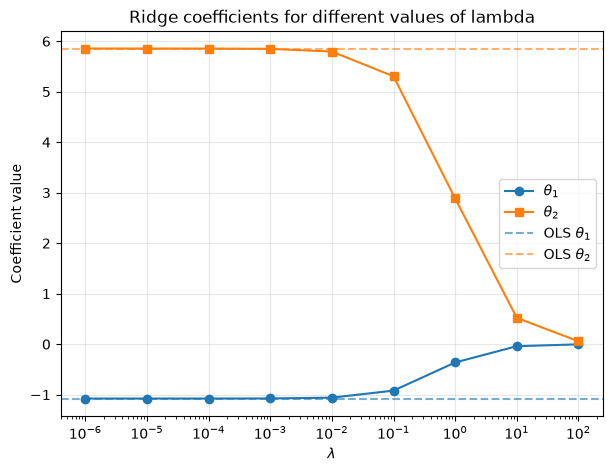

In [24]:
plt.figure(figsize=(7, 5))

plt.plot(
    lambdas,
    ridge_coefficients[:, 0],
    "o-",
    label=r"$\theta_1$"
)

plt.plot(
    lambdas,
    ridge_coefficients[:, 1],
    "s-",
    label=r"$\theta_2$"
)

# OLS coefficients for comparison
plt.axhline(
    theta_closed_formOLS[0],
    color="C0",
    linestyle="--",
    alpha=0.6,
    label=r"OLS $\theta_1$"
)

plt.axhline(
    theta_closed_formOLS[1],
    color="C1",
    linestyle="--",
    alpha=0.6,
    label=r"OLS $\theta_2$"
)

plt.xscale("log")
plt.xlabel(r"$\lambda$")
plt.ylabel("Coefficient value")
plt.title("Ridge coefficients for different values of lambda")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

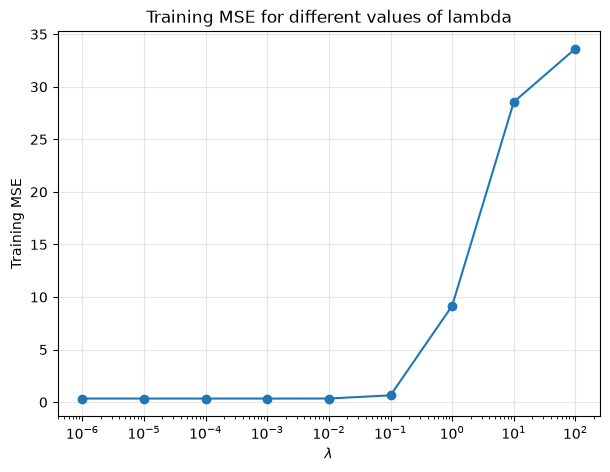

In [25]:
plt.figure(figsize=(7, 5))

plt.plot(
    lambdas,
    training_mse,
    "o-"
)

plt.xscale("log")
plt.xlabel(r"$\lambda$")
plt.ylabel("Training MSE")
plt.title("Training MSE for different values of lambda")
plt.grid(alpha=0.3)
plt.show()

For very small values of $\lambda$, the Ridge coefficients are almost the
same as the OLS coefficients. This is because the Ridge penalty is very weak.

As $\lambda$ increases, both coefficients move towards zero. For example,
the coefficients change from approximately

$$
(-1.077,\;5.855)
$$

at $\lambda=10^{-6}$ to

$$
(-0.004,\;0.057)
$$

at $\lambda=100$.

At the same time, the training MSE increases from approximately $0.343$ to
$33.64$. A very large $\lambda$ makes the coefficients too small, so the
model underfits the data.

Therefore, $\lambda$ controls the balance between fitting the training data
and keeping the coefficients small. In practice, we should select $\lambda$
using cross-validation rather than training MSE.

## Exercise 4: implementing the simplest form of gradient descent

In [ ]:

gamma = 0.1

num_iters = 1000
tol = 1e-8


theta_gdOLS = np.zeros(n_features)
theta_gdRidge = np.zeros(n_features)

# Gradient descent loop
for t in range(num_iters):
   
    grad_OLS = 2/n * x_norm.T @ (x_norm @ theta_gdOLS - y_centered)
    grad_Ridge = 2/n * x_norm.T @ (x_norm @ theta_gdRidge - y_centered) 
       + 2 * lam * theta_gdRidge
  
    theta_gdOLS = theta_gdOLS - gamma * grad_OLS
    theta_gdRidge = theta_gdRidge - gamma * grad_Ridge

  
    if np.linalg.norm(grad_OLS) < tol:
        print(f"OLS converged after {t+1} iterations")
        break
    if np.linalg.norm(grad_Ridge) < tol:
        print(f"Ridge converged after {t+1} iterations")
        break

# After the loop, theta contains the fitted coefficients
print("Gradient Descent OLS coefficients:", theta_gdOLS)
print("Gradient Descent Ridge coefficients:", theta_gdRidge)

Ridge converged after 106 iterations
Gradient Descent OLS coefficients: [-1.0773505  5.854734 ]
Gradient Descent Ridge coefficients: [-1.0596409   5.79468914]


In [ ]:
print( "OLS difference:", np.
  linalg.norm(theta_gdOLS - theta_closed_formOLS ) )

print("Ridge difference:", np.linalg
     .norm(theta_gdRidge - theta_closed_formRidge)
)

OLS difference: 5.773983084640937e-09
Ridge difference: 4.412280702321641e-09


In [ ]:
gamas = [0.01, 0.1, 0.5, 0.8]

max_iters = 20000
accuracy = 1e-6

results_ols= {}
theta_exact = theta_closed_formOLS

for gama in gamas:
    theta= np.zeros(n_features)

    distances= [np.linalg.norm(theta - theta_exact)]

    converged_iteration = None

    for iteration in range(1, max_iters + 1):
        grad= 2/n * (x_norm.T @ (x_norm @ theta - y_centered) )
        theta= theta - gama * grad
        distance = np.linalg.norm(theta - theta_exact)

        distances.append(distance)

        
        if distance < accuracy:
            converged_iteration = iteration
            break


    results_ols[gama] = { "theta": theta.copy(),
                        "distances": np.array(distances),
                        "iterations": converged_iteration }


    if converged_iteration is not None:
        print(f"Gamma: {gama}, Converged in {converged_iteration} iterations")

    else: 
        print(f"Gamma: {gama}, Did not converge within {max_iters} iterations")



Gamma: 0.01, Converged in 867 iterations
Gamma: 0.1, Converged in 80 iterations
Gamma: 0.5, Converged in 8 iterations
Gamma: 0.8, Converged in 64 iterations


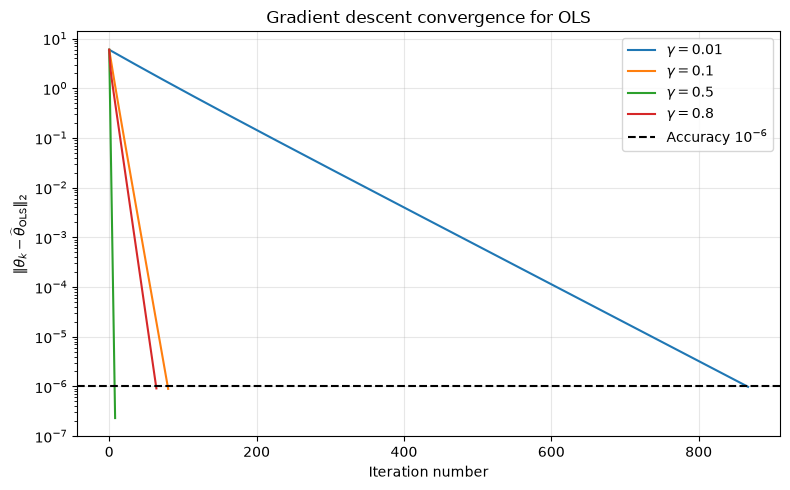

In [35]:
plt.figure(figsize=(8, 5))

for gama in gamas:

    distances = results_ols[gama]["distances"]

    plt.semilogy( range(len(distances)),distances, label=fr"$\gamma={gama}$")



plt.axhline(accuracy, color="black", linestyle="--", label=r"Accuracy $10^{-6}$")

plt.xlabel("Iteration number")

plt.ylabel( r"$\|\theta_k-\widehat{\theta}_{\mathrm{OLS}}\|_2$")

plt.title("Gradient descent convergence for OLS")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

I implemented gradient descent for OLS and stopped the algorithm when

$$
\|\theta_k-\widehat{\theta}_{\mathrm{OLS}}\|_2<10^{-6}.
$$

The results were:

| Learning rate $\gamma$ | Number of iterations |
|---:|---:|
| $0.01$ | $867$ |
| $0.1$ | $80$ |
| $0.5$ | $8$ |
| $0.8$ | $64$ |

The smallest learning rate, $\gamma=0.01$, converged slowly because its
updates were very small. Increasing the learning rate to $0.1$ made the
convergence faster.

The fastest convergence was obtained with $\gamma=0.5$, which required only
8 iterations. Increasing the learning rate further to $0.8$ did not improve
the result. It required 64 iterations because the algorithm moved back and
forth around the minimum.

Therefore, a larger learning rate is not always faster. The learning rate
must be large enough to make useful progress, but not so large that the
updates oscillate around the minimum.

## 4b

In [ ]:

lam = 0.01
gamma = 0.1
max_iters = 20000
tol = 1e-8

# Number of observations and features
n, n_features = x_norm.shape

theta_ridge = np.zeros(n_features)


gradient_norms = []

converged = False

for iteration in range(1, max_iters + 1):

   
    grad_ridge = (
        (2.0 / n)
        * x_norm.T
        @ (x_norm @ theta_ridge - y_centered)
        + 2.0 * lam * theta_ridge
    )

 
    grad_norm = np.linalg.norm(grad_ridge)

    gradient_norms.append(grad_norm)

  
    if grad_norm < tol:
        converged = True
        break

   
    theta_ridge = (
        theta_ridge
        - gamma * grad_ridge
    )


if converged:
    print(
        f"Ridge converged after {iteration} iterations"
    )
else:
    print(
        f"Ridge did not converge within "
        f"{max_iters} iterations"
    )

print(
    "Gradient Descent Ridge coefficients:",
    theta_ridge
)

print(
    "Final gradient norm:",
    gradient_norms[-1]
)

Ridge converged after 106 iterations
Gradient Descent Ridge coefficients: [-1.0596409   5.79468914]
Final gradient norm: 9.574639242548684e-09



I implemented gradient descent for Ridge regression using

$$
\nabla_{\theta}C_{\mathrm{Ridge}}
=
\frac{2}{n}X^T(X\theta-y)+2\lambda\theta.
$$

I used $\lambda=0.01$, $\gamma=0.1$, and stopped the algorithm when

$$
\|\nabla_{\theta}C_{\mathrm{Ridge}}\|_2<10^{-8}.
$$

The closed-form Ridge coefficients were

$$
\widehat{\theta}_{\mathrm{Ridge}}
=
[-1.0596409,\;5.79468915].
$$

The distance between the gradient descent result and the closed-form solution
was

$$
5.37\times10^{-9}.
$$

This distance is very small, so the gradient descent result agrees with the
analytical solution.

A fixed number of iterations alone is not a reliable stopping criterion. It
may stop the algorithm before convergence, or it may continue running after
convergence. Therefore, I used both a maximum number of iterations and a
condition based on the gradient norm.

## 4c

In [58]:
# OLS Hessian for degree 2
n = x_norm.shape[0]

H2 = (
    (2.0 / n)
    * x_norm.T
    @ x_norm
)

eigenvalues2 = np.linalg.eigvalsh(H2)

lambda_min2 = eigenvalues2.min()
lambda_max2 = eigenvalues2.max()

kappa2 = lambda_max2 / lambda_min2
gamma_max2 = 2.0 / lambda_max2
gamma_star2 = 2.0 / (lambda_max2 + lambda_min2)

print("Degree 2 eigenvalues:", eigenvalues2)
print("lambda_min:", lambda_min2)
print("lambda_max:", lambda_max2)
print("condition number:", kappa2)
print("gamma_max:", gamma_max2)
print("gamma_star:", gamma_star2)

Degree 2 eigenvalues: [1.76307062 2.23692938]
lambda_min: 1.7630706238245226
lambda_max: 2.236929376175477
condition number: 1.2687690135310865
gamma_max: 0.8940827642128962
gamma_star: 0.5000000000000001


In [ ]:

x_raw = x[:, 0]


X5 = np.column_stack([
    x_raw**power
    for power in range(1, 6)
])


X5_mean = X5.mean(axis=0)
X5_std = X5.std(axis=0)

x5_norm = (
    (X5 - X5_mean)
    / X5_std
)

print("Shape:", x5_norm.shape)
print("Rank:", np.linalg.matrix_rank(x5_norm))

Shape: (100, 5)
Rank: 5


In [61]:
H5 = (
    (2.0 / n)
    * X5_norm.T
    @ X5_norm
)

eigenvalues5 = np.linalg.eigvalsh(H5)

lambda_min5 = eigenvalues5.min()
lambda_max5 = eigenvalues5.max()

kappa5 = lambda_max5 / lambda_min5
gamma_max5 = 2.0 / lambda_max5
gamma_star5 = 2.0 / (lambda_max5 + lambda_min5)

print("Degree 5 eigenvalues:", eigenvalues5)
print("lambda_min:", lambda_min5)
print("lambda_max:", lambda_max5)
print("condition number:", kappa5)
print("gamma_max:", gamma_max5)
print("gamma_star:", gamma_star5)

Degree 5 eigenvalues: [0.01086346 0.0748892  0.40845636 3.85305404 5.65273694]
lambda_min: 0.010863455778780121
lambda_max: 5.652736939256739
condition number: 520.3442674566211
gamma_max: 0.35381090991702396
gamma_star: 0.3531322587224053


In [62]:
def ols_distance_history(X, y, gamma, num_iters=6000):

    n, n_features = X.shape

    theta = np.zeros(n_features)

    theta_exact = np.linalg.solve(
        X.T @ X,
        X.T @ y
    )

    distances = [
        np.linalg.norm(theta - theta_exact)
    ]

    for iteration in range(num_iters):

        gradient = (
            (2.0 / n)
            * X.T
            @ (X @ theta - y)
        )

        theta = theta - gamma * gradient

        distance = np.linalg.norm(
            theta - theta_exact
        )

        distances.append(distance)

        if not np.isfinite(distance) or distance > 1e12:
            break

    return np.array(distances)

In [64]:
gamma_below2 = 0.99 * gamma_max2
gamma_above2 = 1.02 * gamma_max2

distance_below2 = ols_distance_history(
    x_norm,
    y_centered,
    gamma_below2
)

distance_above2 = ols_distance_history(
    x_norm,
    y_centered,
    gamma_above2
)

In [65]:
gamma_below5 = 0.99 * gamma_max5
gamma_above5 = 1.02 * gamma_max5

distance_below5 = ols_distance_history(
    X5_norm,
    y_centered,
    gamma_below5
)

distance_above5 = ols_distance_history(
    X5_norm,
    y_centered,
    gamma_above5
)

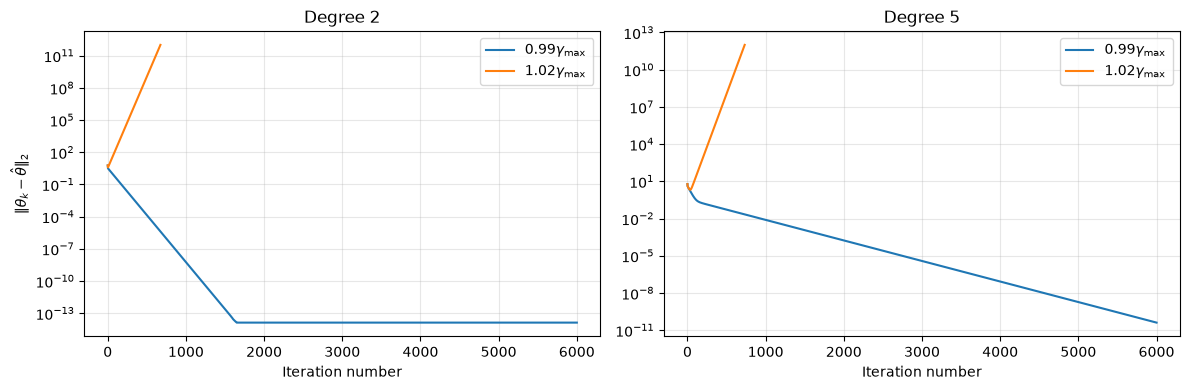

In [66]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].semilogy(
    distance_below2,
    label=r"$0.99\gamma_{\max}$"
)

axes[0].semilogy(
    distance_above2,
    label=r"$1.02\gamma_{\max}$"
)

axes[0].set_title("Degree 2")
axes[0].set_xlabel("Iteration number")
axes[0].set_ylabel(
    r"$\|\theta_k-\hat{\theta}\|_2$"
)
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].semilogy(
    distance_below5,
    label=r"$0.99\gamma_{\max}$"
)

axes[1].semilogy(
    distance_above5,
    label=r"$1.02\gamma_{\max}$"
)

axes[1].set_title("Degree 5")
axes[1].set_xlabel("Iteration number")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

For the degree-5 design matrix, the maximum stable learning rate is

$$
\gamma_{\max}
=
\frac{2}{\lambda_{\max}}
=
0.3538.
$$

Therefore,

$$
0.99\gamma_{\max}=0.3503
$$

is slightly below the stability limit, and gradient descent converges.
However, because it is close to the limit, the iterations may oscillate.

In contrast,

$$
1.02\gamma_{\max}=0.3609
$$

is above the stability limit, so gradient descent diverges. This numerical
experiment confirms the theoretical condition

$$
\boxed{\gamma<\frac{2}{\lambda_{\max}}}.
$$

## 4d

In [68]:
import numpy as np
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from jax import grad

In [69]:
def cost_OLS(theta, X, y):

    n = X.shape[0]

    return (
        jnp.sum((X @ theta - y)**2)
        / n
    )


def cost_Ridge(theta, X, y, lam):

    n = X.shape[0]

    return (
        jnp.sum((X @ theta - y)**2)
        / n
        + lam * jnp.sum(theta**2)
    )

In [70]:
n, n_features = x_norm.shape

rng = np.random.default_rng(2026)

theta_test = rng.standard_normal(n_features)

print("theta_test:", theta_test)

theta_test: [-0.79312248  0.24057128]


In [73]:
H5 = (
    (2.0 / n)
    * X5_norm.T
    @ X5_norm
)

eigenvalues5 = np.linalg.eigvalsh(H5)

lambda_min5 = eigenvalues5.min()
lambda_max5 = eigenvalues5.max()

kappa5 = lambda_max5 / lambda_min5

gamma_max5 = 2.0 / lambda_max5

gamma_star5 = (
    2.0
    / (lambda_max5 + lambda_min5)
)

print("Degree 5 eigenvalues:", eigenvalues5)
print("lambda_min:", lambda_min5)
print("lambda_max:", lambda_max5)
print("condition number:", kappa5)
print("gamma_max:", gamma_max5)
print("gamma_star:", gamma_star5)

Degree 5 eigenvalues: [0.01086346 0.0748892  0.40845636 3.85305404 5.65273694]
lambda_min: 0.010863455778780121
lambda_max: 5.652736939256739
condition number: 520.3442674566211
gamma_max: 0.35381090991702396
gamma_star: 0.3531322587224053


In [74]:
lam= 0.01
grad_Ridge_ad = grad(cost_Ridge)(
    theta_test,
    jnp.asarray(x_norm),
    jnp.asarray(y_centered),
    lam
)


grad_Ridge_analytical = (
    (2.0 / n)
    * x_norm.T
    @ (x_norm @ theta_test - y_centered)
    + 2.0 * lam * theta_test
)


print("Automatic Ridge gradient:")
print(np.asarray(grad_Ridge_ad))

print("\nAnalytical Ridge gradient:")
print(grad_Ridge_analytical)

print(
    "\nmax |AD - analytical| =",
    np.max(
        np.abs(
            np.asarray(grad_Ridge_ad)
            - grad_Ridge_analytical
        )
    )
)

Automatic Ridge gradient:
[ -0.77756646 -11.15617204]

Analytical Ridge gradient:
[ -0.77756646 -11.15617204]

max |AD - analytical| = 1.1102230246251565e-16


In [75]:
gamma = 0.1
num_iters = 200

theta_auto = jnp.zeros(n_features)

grad_cost_OLS = grad(cost_OLS)


for iteration in range(num_iters):

    gradient_auto = grad_cost_OLS(
        theta_auto,
        jnp.asarray(x_norm),
        jnp.asarray(y_centered)
    )

    theta_auto = (
        theta_auto
        - gamma * gradient_auto
    )


print("OLS coefficients using automatic gradient:")
print(np.asarray(theta_auto))

print("\nClosed-form OLS coefficients:")
print(theta_closed_formOLS)

print(
    "\nDistance from closed-form solution:",
    np.linalg.norm(
        np.asarray(theta_auto)
        - theta_closed_formOLS
    )
)

OLS coefficients using automatic gradient:
[-1.0773505  5.854734 ]

Closed-form OLS coefficients:
[-1.0773505  5.854734 ]

Distance from closed-form solution: 1.897149936107019e-15


In [76]:
theta_auto = jnp.zeros(n_features)
theta_analytical = np.zeros(n_features)

maximum_iterate_difference = 0.0


for iteration in range(100):

    gradient_auto = grad(cost_OLS)(
        theta_auto,
        jnp.asarray(x_norm),
        jnp.asarray(y_centered)
    )

    gradient_analytical = (
        (2.0 / n)
        * x_norm.T
        @ (
            x_norm @ theta_analytical
            - y_centered
        )
    )

    theta_auto = (
        theta_auto
        - gamma * gradient_auto
    )

    theta_analytical = (
        theta_analytical
        - gamma * gradient_analytical
    )

    current_difference = np.linalg.norm(
        np.asarray(theta_auto)
        - theta_analytical
    )

    maximum_iterate_difference = max(
        maximum_iterate_difference,
        current_difference
    )


print(
    "Maximum difference between iterates:",
    maximum_iterate_difference
)

Maximum difference between iterates: 9.155133597044475e-16


At the test point

$$
\boldsymbol{\theta}_{\mathrm{test}}
=
(-0.7931,\;0.2406),
$$

the automatic Ridge gradient and the analytical Ridge gradient are both

$$
\nabla C_{\mathrm{Ridge}}
=
(-0.7776,\;-11.1562).
$$

The maximum absolute difference is

$$
1.11\times10^{-nant16},
$$

which is effectively zero and is caused only by floating-point rounding.
Therefore, the analytical Ridge gradient is verified by JAX automatic
differentiation.

In [77]:
gamma = 0.1
num_iters = 100

theta_analytical = np.zeros(n_features)
theta_auto = jnp.zeros(n_features)

grad_OLS_function = grad(cost_OLS)

max_iteration_difference = 0.0

for iteration in range(num_iters):

    # Analytical gradient
    gradient_analytical = (
        (2.0 / n)
        * x_norm.T
        @ (x_norm @ theta_analytical - y_centered)
    )

    theta_analytical = (
        theta_analytical
        - gamma * gradient_analytical
    )

    # Automatic gradient
    gradient_auto = grad_OLS_function(
        theta_auto,
        jnp.asarray(x_norm),
        jnp.asarray(y_centered)
    )

    theta_auto = (
        theta_auto
        - gamma * gradient_auto
    )

    difference = np.linalg.norm(
        theta_analytical
        - np.asarray(theta_auto)
    )

    max_iteration_difference = max(
        max_iteration_difference,
        difference
    )


print("OLS analytical-gradient result:")
print(theta_analytical)

print("\nOLS automatic-gradient result:")
print(np.asarray(theta_auto))

print(
    "\nMaximum difference between iterates:",
    max_iteration_difference
)

OLS analytical-gradient result:
[-1.07735049  5.85473399]

OLS automatic-gradient result:
[-1.07735049  5.85473399]

Maximum difference between iterates: 9.155133597044475e-16


In [78]:
lam = 0.01
gamma = 0.1
num_iters = 100

theta_analytical = np.zeros(n_features)
theta_auto = jnp.zeros(n_features)

grad_Ridge_function = grad(cost_Ridge)

max_iteration_difference = 0.0

for iteration in range(num_iters):

    # Analytical Ridge gradient
    gradient_analytical = (
        (2.0 / n)
        * x_norm.T
        @ (x_norm @ theta_analytical - y_centered)
        + 2.0 * lam * theta_analytical
    )

    theta_analytical = (
        theta_analytical
        - gamma * gradient_analytical
    )

    # Automatic Ridge gradient
    gradient_auto = grad_Ridge_function(
        theta_auto,
        jnp.asarray(x_norm),
        jnp.asarray(y_centered),
        lam
    )

    theta_auto = (
        theta_auto
        - gamma * gradient_auto
    )

    difference = np.linalg.norm(
        theta_analytical
        - np.asarray(theta_auto)
    )

    max_iteration_difference = max(
        max_iteration_difference,
        difference
    )


print("Ridge analytical-gradient result:")
print(theta_analytical)

print("\nRidge automatic-gradient result:")
print(np.asarray(theta_auto))

print(
    "\nMaximum difference between iterates:",
    max_iteration_difference
)

Ridge analytical-gradient result:
[-1.05964089  5.79468914]

Ridge automatic-gradient result:
[-1.05964089  5.79468914]

Maximum difference between iterates: 9.155133597044475e-16


The gradients obtained using automatic differentiation agree with the
analytical OLS and Ridge gradients up to floating-point precision. The
maximum difference was approximately

$$
10^{-16},
$$

which is effectively zero.

Using the automatic and analytical gradients in gradient descent also
produced the same parameter values at every iteration.

Automatic differentiation is not symbolic differentiation because it does
not construct and simplify an algebraic derivative formula. It is also not
finite-difference differentiation because it does not approximate the
gradient by perturbing the parameters. Instead, it applies the chain rule
directly through the operations used to evaluate the cost function.

Using reverse-mode automatic differentiation, computing the complete gradient
usually costs only a small multiple of one cost-function evaluation.

## Exercise 5: Ridge regression and a new synthetic data set

In [79]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

n_samples = 100
n_features = 10

theta_true = np.array([
    5.0, -3.0, 0.0, 0.0, 0.0,
    0.0, 2.0, 0.0, 0.0, 0.0
])

X = np.random.randn(
    n_samples,
    n_features
)

noise = 0.5 * np.random.randn(n_samples)

y = X @ theta_true + noise

In [80]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X_norm = (
    (X - X_mean)
    / X_std
)

y_mean = y.mean()

y_centered = y - y_mean

print(
    "Feature means:",
    np.round(X_norm.mean(axis=0), 12)
)

print(
    "Feature standard deviations:",
    np.round(X_norm.std(axis=0), 12)
)

print(
    "Target mean:",
    np.round(y_centered.mean(), 12)
)

Feature means: [-0.  0.  0.  0. -0. -0. -0. -0. -0.  0.]
Feature standard deviations: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Target mean: 0.0


In [81]:
n, p = X_norm.shape

lam = 0.01

I = np.eye(p)


theta_OLS_closed = np.linalg.solve(
    X_norm.T @ X_norm,
    X_norm.T @ y_centered
)


theta_Ridge_closed = np.linalg.solve(
    X_norm.T @ X_norm
    + n * lam * I,
    X_norm.T @ y_centered
)


print("True coefficients:")
print(theta_true)

print("\nClosed-form OLS:")
print(np.round(theta_OLS_closed, 4))

print("\nClosed-form Ridge:")
print(np.round(theta_Ridge_closed, 4))

True coefficients:
[ 5. -3.  0.  0.  0.  0.  2.  0.  0.  0.]

Closed-form OLS:
[ 5.0324e+00 -2.8926e+00 -1.5500e-02  1.5180e-01 -6.8300e-02 -4.4000e-02
  1.7700e+00  4.4000e-03  4.5300e-02 -4.9800e-02]

Closed-form Ridge:
[ 4.9804 -2.8568 -0.0155  0.1566 -0.0781 -0.0509  1.7538  0.0068  0.0343
 -0.0488]


In [82]:
theta_OLS_original = (
    theta_OLS_closed
    / X_std
)

theta_Ridge_original = (
    theta_Ridge_closed
    / X_std
)


intercept_OLS = (
    y_mean
    - X_mean @ theta_OLS_original
)

intercept_Ridge = (
    y_mean
    - X_mean @ theta_Ridge_original
)


print("True coefficients:")
print(theta_true)

print("\nOLS coefficients on original scale:")
print(np.round(theta_OLS_original, 4))

print("\nRidge coefficients on original scale:")
print(np.round(theta_Ridge_original, 4))

print("\nOLS intercept:", intercept_OLS)
print("Ridge intercept:", intercept_Ridge)

True coefficients:
[ 5. -3.  0.  0.  0.  0.  2.  0.  0.  0.]

OLS coefficients on original scale:
[ 5.0146e+00 -3.0016e+00 -1.7200e-02  1.4690e-01 -6.9500e-02 -4.2900e-02
  2.0550e+00  4.2000e-03  4.2000e-02 -5.5400e-02]

Ridge coefficients on original scale:
[ 4.9628 -2.9645 -0.0171  0.1515 -0.0794 -0.0497  2.0362  0.0065  0.0318
 -0.0544]

OLS intercept: 0.025503244522507407
Ridge intercept: 0.016284427131284973


In [83]:
gamma = 0.1
max_iters = 10000
tol = 1e-8

theta_gdOLS = np.zeros(p)
theta_gdRidge = np.zeros(p)


for iteration in range(max_iters):

    grad_OLS = (
        (2.0 / n)
        * X_norm.T
        @ (X_norm @ theta_gdOLS - y_centered)
    )

    grad_Ridge = (
        (2.0 / n)
        * X_norm.T
        @ (X_norm @ theta_gdRidge - y_centered)
        + 2.0 * lam * theta_gdRidge
    )


    theta_gdOLS_new = (
        theta_gdOLS
        - gamma * grad_OLS
    )

    theta_gdRidge_new = (
        theta_gdRidge
        - gamma * grad_Ridge
    )


    change_OLS = np.linalg.norm(
        theta_gdOLS_new - theta_gdOLS
    )

    change_Ridge = np.linalg.norm(
        theta_gdRidge_new - theta_gdRidge
    )


    theta_gdOLS = theta_gdOLS_new
    theta_gdRidge = theta_gdRidge_new


    if (
        change_OLS < tol
        and change_Ridge < tol
    ):
        break


print("Number of iterations:", iteration + 1)

print("\nGradient Descent OLS:")
print(np.round(theta_gdOLS, 4))

print("\nClosed-form OLS:")
print(np.round(theta_OLS_closed, 4))

print(
    "\nOLS difference:",
    np.linalg.norm(
        theta_gdOLS
        - theta_OLS_closed
    )
)


print("\nGradient Descent Ridge:")
print(np.round(theta_gdRidge, 4))

print("\nClosed-form Ridge:")
print(np.round(theta_Ridge_closed, 4))

print(
    "\nRidge difference:",
    np.linalg.norm(
        theta_gdRidge
        - theta_Ridge_closed
    )
)

Number of iterations: 131

Gradient Descent OLS:
[ 5.0324e+00 -2.8926e+00 -1.5500e-02  1.5180e-01 -6.8300e-02 -4.4000e-02
  1.7700e+00  4.4000e-03  4.5300e-02 -4.9800e-02]

Closed-form OLS:
[ 5.0324e+00 -2.8926e+00 -1.5500e-02  1.5180e-01 -6.8300e-02 -4.4000e-02
  1.7700e+00  4.4000e-03  4.5300e-02 -4.9800e-02]

OLS difference: 6.373338365549138e-08

Gradient Descent Ridge:
[ 4.9804 -2.8568 -0.0155  0.1566 -0.0781 -0.0509  1.7538  0.0068  0.0343
 -0.0488]

Closed-form Ridge:
[ 4.9804 -2.8568 -0.0155  0.1566 -0.0781 -0.0509  1.7538  0.0068  0.0343
 -0.0488]

Ridge difference: 4.6467128133981656e-08


In [84]:
ols_coefficient_error = np.linalg.norm(
    theta_OLS_original
    - theta_true
)

ridge_coefficient_error = np.linalg.norm(
    theta_Ridge_original
    - theta_true
)


print(
    "OLS coefficient error:",
    ols_coefficient_error
)

print(
    "Ridge coefficient error:",
    ridge_coefficient_error
)

OLS coefficient error: 0.19142097079904838
Ridge coefficient error: 0.20002772906669636


In [85]:
y_pred_OLS = (
    intercept_OLS
    + X @ theta_OLS_original
)

y_pred_Ridge = (
    intercept_Ridge
    + X @ theta_Ridge_original
)


mse_OLS = np.mean(
    (y - y_pred_OLS)**2
)

mse_Ridge = np.mean(
    (y - y_pred_Ridge)**2
)


print("OLS training MSE:", mse_OLS)
print("Ridge training MSE:", mse_Ridge)

OLS training MSE: 0.16850284715175223
Ridge training MSE: 0.17238326257578548


In [86]:
H_OLS = (
    (2.0 / n)
    * X_norm.T
    @ X_norm
)

eigenvalues_OLS = np.linalg.eigvalsh(
    H_OLS
)

lambda_min = eigenvalues_OLS.min()
lambda_max = eigenvalues_OLS.max()

kappa_OLS = (
    lambda_max
    / lambda_min
)


H_Ridge = (
    H_OLS
    + 2.0 * lam * np.eye(p)
)

eigenvalues_Ridge = np.linalg.eigvalsh(
    H_Ridge
)

kappa_Ridge = (
    eigenvalues_Ridge.max()
    / eigenvalues_Ridge.min()
)


print("OLS eigenvalues:")
print(eigenvalues_OLS)

print("\nOLS condition number:", kappa_OLS)
print("Ridge condition number:", kappa_Ridge)

OLS eigenvalues:
[1.26447987 1.40019702 1.48665226 1.74907753 1.80480277 2.11107206
 2.18135639 2.48416801 2.65286182 2.86533227]

OLS condition number: 2.2660165081560275
Ridge condition number: 2.2463039920641674


The OLS coefficient error is

$$
0.1914,
$$

while the Ridge coefficient error is

$$
0.2000.
$$

Therefore, OLS recovers the true coefficients slightly more accurately in
this experiment.

The OLS training MSE is $0.1685$, while the Ridge training MSE is $0.1724$.
OLS has the smaller training error because it directly minimises the training
sum of squared errors. Ridge accepts a slightly larger training error in
exchange for shrinking the coefficients.

The condition numbers are

$$
\kappa_{\mathrm{OLS}}=2.266
$$

and

$$
\kappa_{\mathrm{Ridge}}=2.246.
$$

Both condition numbers are small, so this data set is already well-conditioned.
Ridge only produces a small improvement in the condition number.

This problem is much better conditioned than the degree-5 polynomial problem,
which had a condition number of approximately

$$
\kappa_{\mathrm{degree\,5}}\approx520.
$$

The features in the new data set were generated independently from a standard
normal distribution, so their columns are not strongly correlated. In
contrast, the polynomial features $x,x^2,\ldots,x^5$ are strongly related.

Therefore, the cost surface for the new data set is more nearly circular and
gradient descent converges more easily. The polynomial problem has a long,
narrow cost surface, which causes much slower convergence.

For this particular data set, Ridge does not provide a clear advantage over
OLS. Ridge would be more helpful for the degree-5 polynomial data because it
raises the small Hessian eigenvalues, reduces the condition number and makes
gradient descent more stable.

## Exercise 6: adding momentum

In [ ]:
def momentum_GD(
    X,
    y,
    gamma,
    beta,
    accuracy=1e-6,
    max_iters=50000
):

    n, n_features = X.shape


    theta_exact = np.linalg.solve(
        X.T @ X,
        X.T @ y
    )

  
    theta = np.zeros(n_features)
    velocity = np.zeros(n_features)

    distances = [
        np.linalg.norm(theta - theta_exact)
    ]

    converged_iteration = None

    for iteration in range(1, max_iters + 1):

        gradient = (
            (2.0 / n)
            * X.T
            @ (X @ theta - y)
        )

        velocity = (
            beta * velocity
            + gamma * gradient
        )

        theta = theta - velocity

        distance = np.linalg.norm(
            theta - theta_exact
        )

        distances.append(distance)

        if distance < accuracy:
            converged_iteration = iteration
            break

        if not np.isfinite(distance) or distance > 1e12:
            break

    return (
        theta,
        np.array(distances),
        converged_iteration
    )

In [88]:
gamma_momentum = (
    0.9
    * 2.0
    / lambda_max5
)

print("gamma:", gamma_momentum)

gamma: 0.3184298189253216


In [89]:
betas = [0.0, 0.5, 0.9]

momentum_results = {}

for beta in betas:

    theta, distances, iterations = momentum_GD(
        X=X5_norm,
        y=y_centered,
        gamma=gamma_momentum,
        beta=beta,
        accuracy=1e-6,
        max_iters=50000
    )

    momentum_results[beta] = {
        "theta": theta,
        "distances": distances,
        "iterations": iterations
    }

    if iterations is None:
        print(
            f"beta = {beta}: "
            "did not converge"
        )
    else:
        print(
            f"beta = {beta}: "
            f"converged after {iterations} iterations"
        )

beta = 0.0: converged after 4731 iterations
beta = 0.5: converged after 2346 iterations
beta = 0.9: converged after 297 iterations


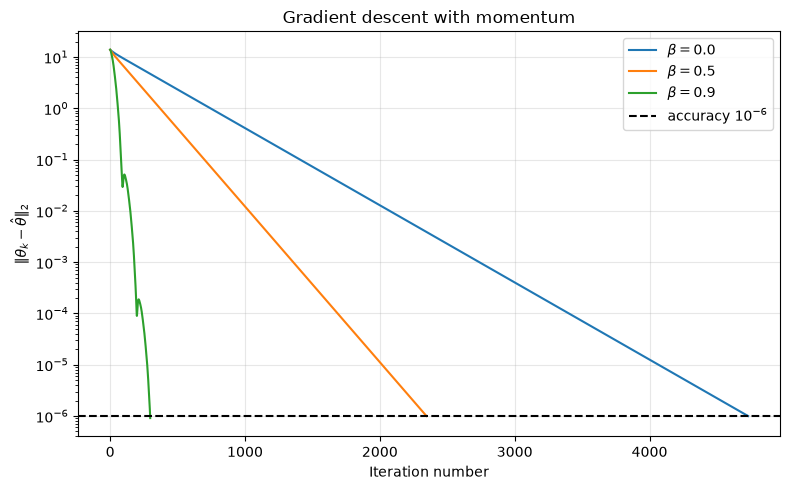

In [90]:
plt.figure(figsize=(8, 5))

for beta in betas:

    distances = momentum_results[beta]["distances"]

    plt.semilogy(
        distances,
        label=fr"$\beta={beta}$"
    )

plt.axhline(
    1e-6,
    color="black",
    linestyle="--",
    label=r"accuracy $10^{-6}$"
)

plt.xlabel("Iteration number")
plt.ylabel(
    r"$\|\theta_k-\hat{\theta}\|_2$"
)

plt.title(
    "Gradient descent with momentum"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [97]:
iterations_plain = momentum_results[0.0]["iterations"]

for beta in betas:

    iterations = momentum_results[beta]["iterations"]

    speedup = iterations_plain / iterations

    print(
        f"beta = {beta}: "
        f"iterations = {iterations}, "
        f"speed-up = {speedup:.2f}"
    )

beta = 0.0: iterations = 4731, speed-up = 1.00
beta = 0.5: iterations = 2346, speed-up = 2.02
beta = 0.9: iterations = 297, speed-up = 15.93


In [98]:
theta_star, distances_star, iterations_star = momentum_GD(
    X=X5_norm,
    y=y_centered,
    gamma=gamma_momentum,
    beta=beta_star,
    accuracy=1e-6,
    max_iters=50000
)

speedup_star = (
    iterations_plain
    / iterations_star
)

print("iterations with beta_star:", iterations_star)
print("speed-up with beta_star:", speedup_star)

iterations with beta_star: 661
speed-up with beta_star: 7.157337367624811


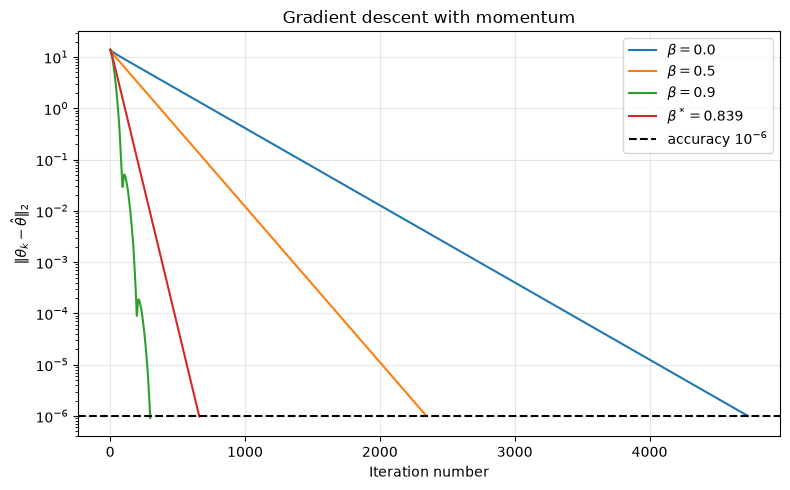

In [99]:
plt.figure(figsize=(8, 5))

for beta in betas:

    plt.semilogy(
        momentum_results[beta]["distances"],
        label=fr"$\beta={beta}$"
    )

plt.semilogy(
    distances_star,
    label=fr"$\beta^*={beta_star:.3f}$"
)

plt.axhline(
    1e-6,
    color="black",
    linestyle="--",
    label=r"accuracy $10^{-6}$"
)

plt.xlabel("Iteration number")

plt.ylabel(
    r"$\|\theta_k-\hat{\theta}\|_2$"
)

plt.title(
    "Gradient descent with momentum"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()